# Introduction

The tutorial sessions during the first day are aimed at introducing the students and new researchers in the field about basic notions on atomic and electronic structure of twisted bilayer graphene. 

To achieve this, we will first focus our attention to single layer graphene, followed by AB-stacked bilayer graphene and then conclude with twisted bilayer graphene where will teach the basics of building a commensurate angle for a chosen twist angle and then use this structure to calculate the electronic band structure and density of states. As a bonus, we provide the reader with a session focused on graphene on hBN.

The input files for the GRABNES code will be generated within this python Jupyter notebook, while the calculations themselves will be running in the background using Fortran. We use the [PyToGrabnes](./PyToGrabnes.py) library written for this purpose.

# Library imports

In [2]:
import PyToGrabnes as pg
import matplotlib.pyplot as plt
import os
import numpy as np

from IPython.display import Image
from IPython.core.display import HTML 

rootDir = "/Users/nihao/github/JeilJungGroupCodes/lanczosKuboCode/docs/notebooks/"

%load_ext autoreload
%autoreload 2

# Graphene

## Introduction

Graphene is probably the most famous two-dimensional allotrope within the materials composed of carbon. The carbon atoms form a 2D sheet of atoms organized in a honeycomb pattern. From a crystallographic perspective, this system can be represented using a unit cell containing two atoms provided the unit vectors are chosen appropriately. This is illustrated in the following figure.

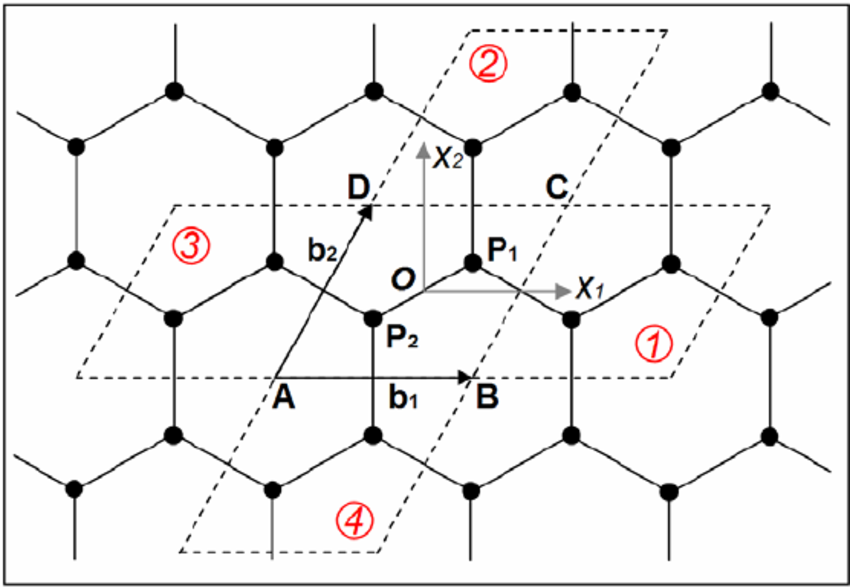

In [10]:
os.chdir(rootDir)
Image(filename = "../figures/grapheneUnitCell.png")

__let's make our own figure__

Figure from Zhou, J; Huang, R. Internal lattice relaxation of single-layer graphene under in-plane deformation. Journal of the Mechanics and Physics of Solids, 2008, 56(4), 1609-1623. https://doi.org/10.1016/j.jmps.2007.07.013

These two carbon atoms are commonly referred to as the A and B sublattice atoms. In pristine graphene, they are equivalent, while when applying a mass-term, they can become inequivalent. In the former case, pristine graphene behaves as a semi-metal while in the latter, one can induce a gap opening in the system.

For this first session, we are going to introduce a bandgap in the system.

## Generating input file

In [2]:
fileName = "Gendata.in"
workingDir = "./Graphene/"
inputStrings = ["Supercell 1", # Size of the supercell, i.e. number of repetitions of the unit cell in the x and y direction
               "CellSize 1" # Number of repetitions of the graphene unit cell, useful when building a larger moire unit cell
               ]
pg.createInputFile(fileName, workingDir, inputStrings)

## Running Calculations

### Electronic structure

### Density of states

#### Zero magnetic field

#### Magnetic field

## Expected output

### Electronic structure

### Density of states

#### Zero magnetic field

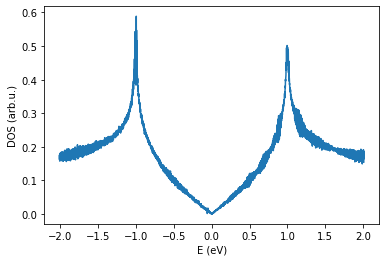

In [3]:
os.chdir(rootDir + "./graphene/output/")
fileName = "generate_supercell30.DOS"
pg.plotDOS(fileName)

#### Magnetic field

## Discussion

# Bernal Stacked Bilayer Graphene

# Twisted Bilayer Graphene

## Introduction

Twisted bilayer graphene has garnered a lot of attention in recent years due to the interesting properties it displays. When twisting the two layers of graphene at a specific twist angle, the hybridization of the two Dirac cone can lead to the formation of a flat band which can give rise to superconductivity and Mott insulator signatures. To simulate this type of moire system, one needs to build a commensurate cell for each of the twist angles one is interested in. As a first approximation, the smaller the twist angle, the larger the moire unit cell. Only a discrete set of twist angles exist, but the larger the unit cell, the more angles become accessible.

A versatile way to describe a moire system is using the 4 indices defined by the [Herman approach](https://iopscience.iop.org/article/10.1088/0953-8984/24/31/314210). This will be our first task in the next section where we will build and visualize the moire unit cell.
We then will use this moire unit cell to calculate the density of states using Lanczox recursion.






## Building the commensurate cell

Create a twisted bilayer system using the `31 30 30 31` indices and visualize the structure. Either using the provided methods, either using an external program such as VMd or xCrysDen.

A table with relevant indices is given in [this reference](https://journals.aps.org/prb/abstract/10.1103/PhysRevB.106.115410). You can use the `create_tBG_commensurate_cell` method that will prepare the [fortran script](GenMoire_tBGTemplate.f90) that will do this and prepares output that can be used as input for a LAMMPS calculation or directly as input for the GRABNES code.

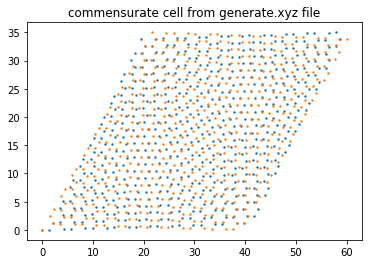

In [17]:
os.chdir(rootDir)
pg.create_tBG_commensurate_cell([10,9,9,10]) # Obtains the commensurate cell using integers
#pg.create_tBG_commensurate_cell(1.08) # Obtains the commensurate cell using an angle estimate
pg.plotStructure("generate.xyz")

## Density of States

### Lanczos DOS

Calculate the Lancoz DOS and optimize the supercell size to get smooth behavior signatures. Note that the TB model we use includes a large number of neighbors, because of this, the memory requirements can become quite large. For the sake of this session, consider small cells up to SuperCell 5.

### Exact diagonalization DOS

Calculate the DOS using exact diagonalization and compare it with the Lanczos DOS.

## Electronic band structure

### Flat band

Calculate the electronic bandstructure and visualize the flat band.